## Clustering

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = '1'

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram

df = pd.read_csv("air_quality.csv")
# df.describe()
aq_mapping = {
    "Hazardous": 1,
    "Poor": 2,
    "Moderate": 3,
    "Good": 4
}

df["Air Quality"] = df["Air Quality"].map(aq_mapping)

features = df.drop(columns=["Air Quality"])
scaler = StandardScaler()
normalized_features = scaler.fit_transform(features)
normalized_df = pd.DataFrame(normalized_features, columns=features.columns)
print(normalized_df.head())




   Temperature  Humidity     PM2.5      PM10       NO2       SO2        CO  \
0    -0.034080 -0.690715 -0.608589 -0.450455 -0.844581 -0.120721  0.402303   
1    -0.257295  0.349507 -0.726706 -0.658892  0.493329 -0.046643  0.255775   
2    -1.031106  0.292768  0.267100  0.130973 -0.226219  0.383011  0.237459   
3    -0.435867 -1.951591 -0.571933 -0.874642 -1.451700 -0.698530 -0.641707   
4    -0.525153  0.040593 -0.539349 -0.519934 -0.507293 -0.654083 -0.898130   

   Proximity_to_Industrial_Areas  Population_Density  
0                      -0.588658           -1.168163  
1                      -0.671748            0.743598  
2                      -0.893318            0.795975  
3                       0.740767            0.350770  
4                       1.183909           -1.272917  


### Task 1: Function for computing purity
function of purity.

The indices of the clusters in `y_true` and `y_pred` start from 0 in `compute_purity`, e.g., [1, 1, 0, 0, 2, 2, 2].

`y_true` is the array of true class indices of all data points, `len(y_true)=number of data points`.

`y_pred` is the array of cluster indices of all data points, `len(y_pred)=number of data points`.

In [14]:
def compute_purity(y_true, y_pred):
    # This is your function of purity
    # y_true is the array of true class indices of all data points, len(y_true)=number of data points
    # y_pred is the array of cluster indices of all data points, len(y_pred)=number of data points

    contingency_matrix = pd.crosstab(y_pred, y_true)
    majority_sum = contingency_matrix.max(axis=1).sum()
    purity = majority_sum / len(y_true)

    return purity

y_pred = [2, 2, 1, 2, 2, 2, 0, 0, 0, 1, 2, 1, 1, 1, 1, 1]
y_true = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2]

purity = compute_purity(y_true, y_pred)
print(f"Purity: {purity * 100:.2f}%")


Purity: 75.00%


### Task 2: Function for computing sum of squared error (sse)
function of sse.

The indices of the clusters in `y_pred` start from 0 in `compute_sse`, e.g., [1, 1, 0, 0, 2, 2, 2].

`x` is the array of data, `x.shape=(numbe of data points, number of attributes)`.

`y_pred` is the array of cluster indices of all data points, `len(y_pred)=number of data points`.

In [10]:
def compute_sse(x, y_pred):
    # This is your function of sse
    # x is the array of data, x.shape=(number of data points, number of attributes)
    # y_pred is the array of cluster indices of all data points, len(y_pred)=number of data points
    sse = 0

    data = pd.DataFrame(x)
    data["Cluster"] = y_pred

    cluster_centers = data.groupby("Cluster").mean()

    for cluster in cluster_centers.index:
        cluster_data = data[data["Cluster"] == cluster].drop(columns=["Cluster"])
        cluster_center = cluster_centers.loc[cluster].values
        squared_distances = np.square(cluster_data - cluster_center).sum(axis=1)
        sse += squared_distances.sum()

    return sse


iris_data = pd.read_csv("Iris.csv")

iris_features = iris_data[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred_iris = kmeans.fit_predict(iris_features)

sse_custom = compute_sse(iris_features.values, y_pred_iris)

sse_kmeans = kmeans.inertia_

print(f"My SSE: {sse_custom:.4f}")
print(f"KMeans SSE (scaled): {sse_kmeans:.4f}")

My SSE: 78.9451
KMeans SSE (scaled): 78.9451


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Task 3

In [15]:
# Run K-Means clustering with k=4 on the normalized data
kmeans = KMeans(n_clusters=4, random_state=42)
y_pred = kmeans.fit_predict(normalized_df)

cluster_counts = pd.Series(y_pred).value_counts(normalize=True) * 100
cluster_percentages = cluster_counts.sort_index()
print("Cluster Percentages (%):")
print(cluster_percentages)


y_true = df["Air Quality"].values
purity_overall = compute_purity(y_true, y_pred)
print(f"Overall Purity: {purity_overall * 100:.2f}%")

clusters = pd.DataFrame({'Cluster': y_pred, 'TrueLabel': y_true})
cluster_purities = {}

for cluster in range(4):
    cluster_data = clusters[clusters['Cluster'] == cluster]
    cluster_purity = cluster_data['TrueLabel'].value_counts().max() / len(cluster_data)
    cluster_purities[cluster] = cluster_purity * 100

# Display cluster-wise purities
print("Cluster-Wise Purities (%):")
for cluster, purity in cluster_purities.items():
    print(f"Cluster {cluster}: {purity:.2f}%")

highest_purity_cluster = max(cluster_purities, key=cluster_purities.get)
print(f"Cluster with the highest purity: Cluster {highest_purity_cluster}")

Cluster Percentages (%):
0    18.18
1    41.38
2     7.32
3    33.12
Name: proportion, dtype: float64
Overall Purity: 81.30%
Cluster-Wise Purities (%):
Cluster 0: 59.19%
Cluster 1: 96.52%
Cluster 2: 46.45%
Cluster 3: 82.13%
Cluster with the highest purity: Cluster 1


### Task 4

In [17]:
from tqdm import tqdm

# Define values of k
k_values = [2, 3, 4, 10, 20, 30]

results = []

for k in tqdm(k_values):  # Use tqdm for progress tracking
    purity_list = []
    sse_list = []

    for _ in range(10):
        # Run K-means clustering
        kmeans = KMeans(n_clusters=k, random_state=None)  # Use random seed for each run
        y_pred = kmeans.fit_predict(normalized_df)

        sse = kmeans.inertia_
        sse_list.append(sse)
        # Purity
        purity = compute_purity(df["Air Quality"].values, y_pred)
        purity_list.append(purity)

    avg_purity = np.mean(purity_list)
    avg_sse = np.mean(sse_list)

    results.append((k, avg_purity, avg_sse))

results_table = pd.DataFrame(results, columns=["k", "Purity", "SSE"])

print("K-Means Experiment Results:")
print(results_table)

results_table.to_csv("kmeans_experiment_results.csv", index=False)

100%|██████████| 6/6 [00:02<00:00,  2.65it/s]

K-Means Experiment Results:
    k   Purity           SSE
0   2  0.59634  27447.015716
1   3  0.76350  22364.604964
2   4  0.80280  19687.694874
3  10  0.87814  14844.681977
4  20  0.89036  12003.423479
5  30  0.89830  10741.957436


### Task 5

In [19]:
# Define eps values to test
eps_values = [0.8, 0.9, 1.0, 1.1, 1.2]

dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
    y_pred = dbscan.fit_predict(normalized_df)

    num_anomalies = (y_pred == -1).sum()  # Count anomalies (-1)
    num_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)

    # Exclude anomalies for purity and SSE calculations
    clustered_indices = y_pred != -1
    y_true_clustered = df["Air Quality"].values[clustered_indices]
    y_pred_clustered = y_pred[clustered_indices]
    data_clustered = normalized_df[clustered_indices]

    purity = compute_purity(y_true_clustered, y_pred_clustered)
    sse = compute_sse(data_clustered.values, y_pred_clustered)

    if num_clusters > 1:  # Silhouette score is not defined for 1 cluster
        silhouette = silhouette_score(data_clustered, y_pred_clustered, metric='euclidean')
    else:
        silhouette = None

    # Append results
    dbscan_results.append((eps, num_clusters, num_anomalies, purity, sse, silhouette))

dbscan_results_table = pd.DataFrame(dbscan_results, columns=[
    "eps", "Number of Clusters", "Number of Anomalies", "Purity", "SSE", "Silhouette Coefficient"
])

print("DBSCAN Experiment Results:")
print(dbscan_results_table)

dbscan_results_table.to_csv("dbscan_experiment_results.csv", index=False)

DBSCAN Experiment Results:
   eps  Number of Clusters  Number of Anomalies    Purity           SSE  \
0  0.8                  12                 2656  0.790102   6850.021544   
1  0.9                  11                 2071  0.666439  10580.821406   
2  1.0                   8                 1532  0.571223  15668.087223   
3  1.1                  10                 1136  0.520963  19746.073374   
4  1.2                   4                  854  0.482393  23556.197082   

   Silhouette Coefficient  
0               -0.009287  
1                0.007289  
2                0.100165  
3                0.097361  
4                0.227144  


### Task 6

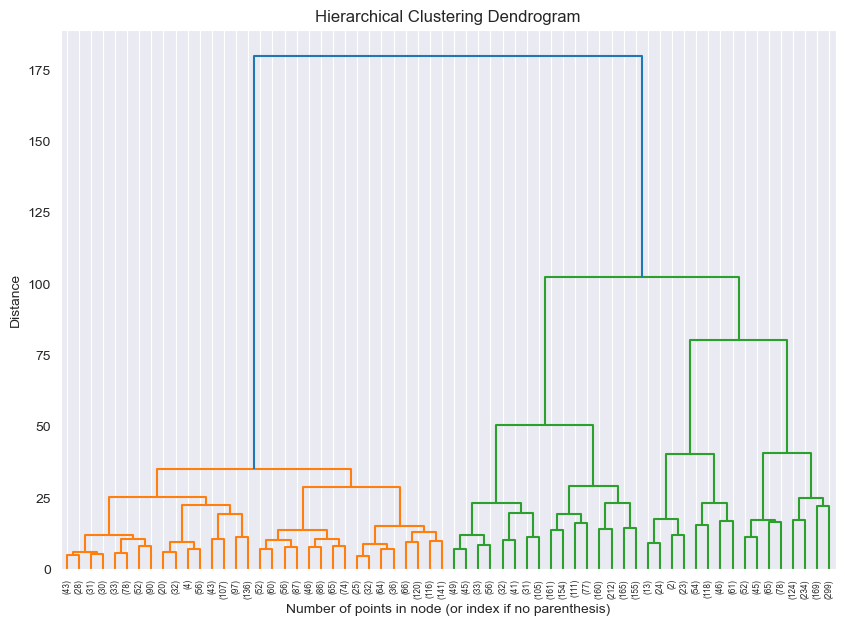

In [23]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

agg_clustering_dendrogram = AgglomerativeClustering(n_clusters=None, distance_threshold=25, linkage='ward')
agg_clustering_dendrogram.fit(normalized_df)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
plot_dendrogram(agg_clustering_dendrogram, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index if no parenthesis)")
plt.ylabel("Distance")
plt.grid(axis='y')
plt.show()

In [24]:
distance_thresholds = [25, 75, 125]
agg_results = []

for threshold in distance_thresholds:
    agg_clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold, linkage='ward')
    y_pred = agg_clustering.fit_predict(normalized_df)

    num_clusters = len(set(y_pred))

    purity = compute_purity(df["Air Quality"].values, y_pred)
    sse = compute_sse(normalized_df.values, y_pred)

    agg_results.append((threshold, purity, sse, num_clusters))

agg_results_table = pd.DataFrame(agg_results, columns=["Distance Threshold", "Purity", "SSE", "Number of Clusters"])

print("Hierarchical Clustering Results:")
print(agg_results_table)

agg_results_table.to_csv("hierarchical_clustering_results.csv", index=False)

Hierarchical Clustering Results:
   Distance Threshold  Purity           SSE  Number of Clusters
0                  25  0.8818  15675.166567                  11
1                  75  0.8450  20364.869108                   4
2                 125  0.6940  28813.695008                   2
